# 10 · Discounted cash flow valuation from SEC data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/10_dcf_valuation.ipynb)

**What you will learn**

- How `client.dcf()` values a company with a two-stage DCF, computed on your machine from the
  filings the client reads.
- How to trace every input of that DCF (free cash flow, net debt, shares) to its `fact_id` and
  the SEC filing it came from.
- How sensitive the value is to the discount rate and terminal growth, what growth the share
  price implies (a reverse DCF), and what the same DCF said on a past date.

**Plan required:** none (free sample tier). The sample covers S&P 500 companies over the last
five years; a paid plan reads the same code against its own universe and history.

Valuein publishes the reported inputs, not an opinion of value: a DCF is only as good as its
assumptions, and those are yours. `client.dcf()` never guesses a growth rate (you must pass one)
and flags every assumption you left at its default. It is the same model as the MCP
`compute_dcf` tool.

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

## 1. History, to inform the growth assumption

`dcf()` needs one number from you: the stage-1 growth rate of free cash flow (FCF = operating
cash flow minus capital expenditure). History is one input to that judgement, so look at it
first. Two data rules for the query below:

- Annual values come from `fiscal_period = 'FY'` rows, `numeric_value`. (On an FY row
  `derived_quarterly_value` is the implied fourth quarter, not the year.)
- The sign of `CAPEX` varies by filer, so take its absolute value.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from valuein_sdk import ValueinClient

TICKER = "MSFT"
client = ValueinClient()
cik = client.resolve(TICKER)["cik"].iloc[0]

flows = client.run_query(f"""
    SELECT period_end, standard_concept, numeric_value
    FROM fact
    WHERE entity_id = '{cik}' AND fiscal_period = 'FY'
      AND standard_concept IN ('TotalRevenue', 'OperatingCashFlow', 'CAPEX')
      AND (period_span_days BETWEEN 350 AND 380 OR period_start IS NULL)
    QUALIFY ROW_NUMBER() OVER (PARTITION BY standard_concept, period_end ORDER BY accepted_at DESC, priority DESC) = 1
""").pivot(index="period_end", columns="standard_concept", values="numeric_value").sort_index()
flows["FCF"] = flows["OperatingCashFlow"] - flows["CAPEX"].abs()
flows["FCF_margin"] = flows["FCF"] / flows["TotalRevenue"]

years_of_history = (flows.index[-1] - flows.index[0]).days / 365.25
historical_growth = (flows["FCF"].iloc[-1] / flows["FCF"].iloc[0]) ** (1 / years_of_history) - 1
print(f"historical FCF growth: {historical_growth:.1%} per year over {years_of_history:.1f} years")

shown = flows.copy()
for column in ["TotalRevenue", "OperatingCashFlow", "CAPEX", "FCF"]:
    shown[column] = shown[column] / 1e9  # USD billions
shown.round(3)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


historical FCF growth: 3.6% per year over 5.0 years


standard_concept,CAPEX,OperatingCashFlow,TotalRevenue,FCF,FCF_margin
period_end,,,,,
2021-06-30,20.622,76.740,168.088,56.118,0.334
2022-06-30,23.886,89.035,198.270,65.149,0.329
2023-06-30,28.107,87.582,211.915,59.475,0.281
2024-06-30,44.477,118.548,245.122,74.071,0.302
2025-06-30,64.551,136.162,281.724,71.611,0.254
2026-06-30,115.948,182.935,331.839,66.987,0.202


## 2. Run the DCF

The model, stated once so you can check it:

- **FCF base** = `OperatingCashFlow` - |`CAPEX`| from the latest annual filing (10-K or 20-F)
  accepted on or before the client's `as_of`.
- **Stage 1**: the base grows at `stage1_growth_rate` for `stage1_years` years, each year
  discounted at `wacc`.
- **Terminal value** = the following year's FCF / (`wacc` - `terminal_growth_rate`), discounted
  back `stage1_years`.
- **Equity** = enterprise value - net debt, where net debt = `TotalDebt` - (`CashAndEquivalents`
  + `ShortTermInvestments`). **Per share** = equity / `CommonSharesOutstanding`.

The growth rate below is the historical one, capped to 0..15%: a placeholder for your own view.
Leave `wacc`, `terminal_growth_rate` or `stage1_years` out and the result flags the default it
used. A bad combination (for example `wacc <= terminal_growth_rate`) raises before any data is
read.

In [3]:
growth = float(np.clip(historical_growth, 0.0, 0.15))
result = client.dcf(TICKER, stage1_growth_rate=growth, wacc=0.09, terminal_growth_rate=0.025)

print(f"fiscal year end    : {result.period_end}")
print(f"enterprise value   : {result.enterprise_value / 1e9:,.1f} bn")
print(f"net debt           : {result.net_debt / 1e9:,.1f} bn ({result.net_debt_basis})")
print(f"equity value       : {result.equity_value / 1e9:,.1f} bn")
print(f"shares             : {result.shares_outstanding / 1e9:,.3f} bn ({result.shares_source})")
print(f"value per share    : {result.value_per_share:,.2f}")
print(f"last close         : {result.price:,.2f} on {result.price_date}")
print(f"upside             : {result.upside:+.1%}")
print(f"terminal value     : {result.terminal_value_pct:.0%} of enterprise value")
pd.DataFrame([a.model_dump() for a in result.assumptions])

fiscal year end    : 2026-06-30
enterprise value   : 1,116.7 bn
net debt           : 0.0 bn (debt_undisclosed)
equity value       : 1,116.7 bn
shares             : 7.427 bn (fact_common_shares)
value per share    : 150.36
last close         : 512.90 on 2026-09-30
upside             : -70.7%
terminal value     : 74% of enterprise value


,name,value,is_default
0,stage1_growth_rate,0.036048,False
1,stage1_years,5.000000,True
2,wacc,0.090000,False
3,terminal_growth_rate,0.025000,False


## 3. Every input, traced to its filing

`result.inputs` holds every figure the DCF used. A filing figure carries its `fact_id` and the
SEC accession number of the filing that reported it; a derived figure (`fcf_base`, `net_debt`)
names the inputs it was computed from, and `note` says when something was assumed (for example
cash taken as zero because no cash line was reported). Nothing in the valuation is a number
the code made up.

Read `net_debt_basis` (printed above) before quoting the value. `reported` means debt and cash
both came from the filing; `cash_assumed_zero` means debt was reported with no cash line; and
`debt_undisclosed` means the annual facts carried no `TotalDebt`, so net debt was taken as 0
(cash included) rather than invented. In that case look the debt up in the filing linked below.

`client.filing_links()` turns each accession into links to the filing on sec.gov, so a reviewer
can open the exact document behind each input. Notebook 08 shows how to recompute a `fact_id`
yourself.

In [4]:
inputs = result.inputs_frame()
links = client.filing_links(TICKER, form_types=["10-K", "10-K/A", "20-F", "20-F/A"], limit=10)
links["filing_url"] = (
    links["inline_viewer_url"].fillna(links["document_url"]).fillna(links["sec_url"])
)
traced = inputs.merge(links[["accession_id", "form_type", "filing_url"]], on="accession_id", how="left")
pd.set_option("display.max_colwidth", 80)
traced[["name", "value", "concept", "source", "derived_from", "fact_id", "accession_id",
        "form_type", "filing_url", "note"]]

,name,value,concept,source,derived_from,fact_id,accession_id,form_type,filing_url,note
0,operating_cash_flow,1.829350e+11,OperatingCashFlow,fact,(),27541911c95900f52753234dc410b9e63194e54c87bb6ea7cf7cd768f69a070d,0001193125-26-323660,10-K,https://www.sec.gov/ix?doc=/Archives/edgar/data/789019/000119312526323660/ms...,NaN
1,capex,1.159480e+11,CAPEX,fact,(),d7c7e3b937574b65712041788f9ee71ba56146079f8dd258d97f9ed714d62d55,0001193125-26-323660,10-K,https://www.sec.gov/ix?doc=/Archives/edgar/data/789019/000119312526323660/ms...,NaN
2,cash,2.093500e+10,CashAndEquivalents,fact,(),91b7aeb1740a425ebdfc9d394d7b2b84c8884a4b3a65d0bf1bb830fcc51aff91,0001193125-26-323660,10-K,https://www.sec.gov/ix?doc=/Archives/edgar/data/789019/000119312526323660/ms...,NaN
3,short_term_investments,5.590800e+10,ShortTermInvestments,fact,(),40d4581a73f419ef834c345895e2cc7766cf2591520125e4dfb50f86a6625ce8,0001193125-26-323660,10-K,https://www.sec.gov/ix?doc=/Archives/edgar/data/789019/000119312526323660/ms...,NaN
4,common_shares_outstanding,7.427000e+09,CommonSharesOutstanding,fact,(),6a484f1452cf3669c7837b106df8b45c99e8bb0361d8804f7c5fe23dd6e5db7b,0001193125-26-323660,10-K,https://www.sec.gov/ix?doc=/Archives/edgar/data/789019/000119312526323660/ms...,NaN
5,net_income,1.337490e+11,NetIncome,fact,(),b781120eb8c1e25324b79319d5711d96ecb49c0e6f66d9445e0479a2f0447d30,0001193125-26-323660,10-K,https://www.sec.gov/ix?doc=/Archives/edgar/data/789019/000119312526323660/ms...,NaN
6,eps_diluted,1.795000e+01,EPSDiluted,fact,(),2e260d52c26909a3d8357e2f60efae9716a2fda6a0a675062802bcdcd0f00d91,0001193125-26-323660,10-K,https://www.sec.gov/ix?doc=/Archives/edgar/data/789019/000119312526323660/ms...,NaN
7,fcf_base,6.698700e+10,NaN,derived,"(operating_cash_flow, capex)",NaN,NaN,NaN,NaN,NaN
8,net_debt,0.000000e+00,NaN,derived,"(cash, short_term_investments)",NaN,NaN,NaN,NaN,total debt not reported: net debt taken as 0 (not a reported zero)


## 4. How the value adds up

The explicit years, then the bridge from enterprise value to the value per share. The terminal
value is usually most of a DCF: the line above printed its share.

In [5]:
projection = result.projection_frame()
projection["fcf_bn"] = projection["fcf"] / 1e9
projection["present_value_bn"] = projection["present_value"] / 1e9
print(projection[["year", "fcf_bn", "discount_factor", "present_value_bn"]].round(3).to_string(index=False))
print()
print(f"sum of stage-1 present values : {result.sum_pv_stage1 / 1e9:,.1f} bn")
print(f"present value of terminal     : {result.pv_terminal_value / 1e9:,.1f} bn")
print(f"enterprise value              : {result.enterprise_value / 1e9:,.1f} bn")
print(f"- net debt                    : {result.net_debt / 1e9:,.1f} bn")
print(f"= equity value                : {result.equity_value / 1e9:,.1f} bn")
print(f"/ shares                      : {result.shares_outstanding / 1e9:,.3f} bn")
print(f"= value per share             : {result.value_per_share:,.2f}")

 year  fcf_bn  discount_factor  present_value_bn
    1  69.402            0.917            63.671
    2  71.904            0.842            60.520
    3  74.495            0.772            57.524
    4  77.181            0.708            54.677
    5  79.963            0.650            51.971

sum of stage-1 present values : 288.4 bn
present value of terminal     : 828.4 bn
enterprise value              : 1,116.7 bn
- net debt                    : 0.0 bn
= equity value                : 1,116.7 bn
/ shares                      : 7.427 bn
= value per share             : 150.36


## 5. Sensitivity

The result carries the 5x5 grid the MCP tool returns: the discount rate 2 points either side of
yours, terminal growth half a point either side. Look at the whole grid before quoting one
number.

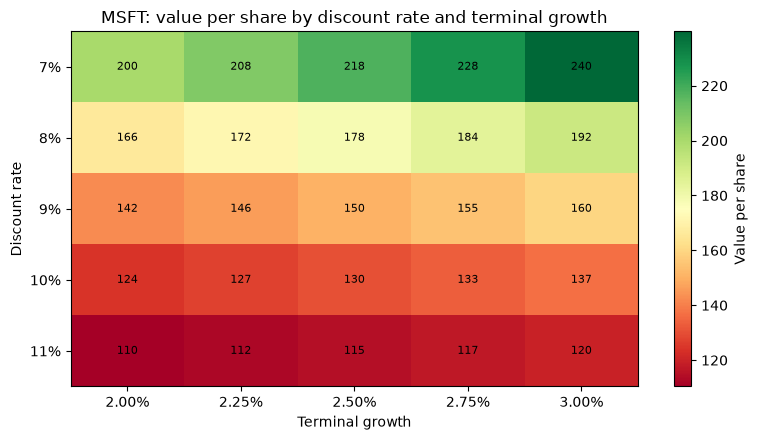

In [6]:
grid = result.sensitivity_frame()
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(grid.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(grid.columns)), [f"{g:.2%}" for g in grid.columns])
ax.set_yticks(range(len(grid.index)), [f"{r:.0%}" for r in grid.index])
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f"{grid.values[i, j]:,.0f}", ha="center", va="center", fontsize=8)
ax.set_xlabel("Terminal growth")
ax.set_ylabel("Discount rate")
ax.set_title(f"{TICKER}: value per share by discount rate and terminal growth")
fig.colorbar(image, ax=ax, label="Value per share")
plt.tight_layout()
plt.show()

## 6. Reverse DCF: what growth does the price imply?

Instead of asking what the company is worth, ask what stage-1 growth makes the DCF equal to the
last close, keeping the other assumptions. The model is simple enough to write down from the
result's own fields; the first line checks that this local copy reproduces `dcf()` to the cent,
then a bisection searches the growth rate.

In [7]:
def per_share(g: float) -> float:
    """The dcf() model at stage-1 growth `g`, every other input taken from `result`."""
    a = {x.name: x.value for x in result.assumptions}
    wacc, gt, n = a["wacc"], a["terminal_growth_rate"], int(a["stage1_years"])
    stage1 = sum(result.fcf_base * (1 + g) ** t / (1 + wacc) ** t for t in range(1, n + 1))
    terminal = result.fcf_base * (1 + g) ** (n + 1) / (wacc - gt) / (1 + wacc) ** n
    return (stage1 + terminal - result.net_debt) / result.shares_outstanding


assert abs(per_share(growth) - result.value_per_share) < 0.01, "local model drifted from dcf()"

low, high = -0.5, 1.0
for _ in range(100):
    mid = (low + high) / 2
    low, high = (mid, high) if per_share(mid) < result.price else (low, mid)
print(f"growth implied by the price : {(low + high) / 2:.1%} per year")
print(f"historical FCF growth       : {historical_growth:.1%} per year")

growth implied by the price : 29.9% per year
historical FCF growth       : 3.6% per year


## 7. The same DCF as known on a past date

`dcf()` reads only filings accepted on or before the client's `as_of`, and the price is the last
close on or before that day. A client opened on a past date answers with the information an
analyst had then: an earlier fiscal year, other `fact_id`s, no look-ahead.

In [8]:
from datetime import datetime, timezone

past = datetime(2024, 6, 30, tzinfo=timezone.utc)
with ValueinClient(as_of=past) as then:
    earlier = then.dcf(TICKER, stage1_growth_rate=growth, wacc=0.09, terminal_growth_rate=0.025)

pd.DataFrame(
    {
        "as_of": [earlier.as_of.date(), result.as_of.date()],
        "fiscal_year_end": [earlier.period_end, result.period_end],
        "fcf_base_bn": [earlier.fcf_base / 1e9, result.fcf_base / 1e9],
        "value_per_share": [earlier.value_per_share, result.value_per_share],
        "price": [earlier.price, result.price],
        "price_date": [earlier.price_date, result.price_date],
    }
).round(2)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  with ValueinClient(as_of=past) as then:


,as_of,fiscal_year_end,fcf_base_bn,value_per_share,price,price_date
0,2024-06-30,2023-06-30,59.48,133.41,446.95,2024-06-28
1,2026-10-09,2026-06-30,66.99,150.36,512.90,2026-09-30


## 8. Cross-check against peers

A DCF is one view; trading multiples are another. `client.peers()` picks companies by SIC code
(or the ones you pass) and reads each one's ratios as known on the client's `as_of`, subject
first.

In [9]:
table = client.peers(TICKER, n=5)
wanted = ["ticker", "name", "is_subject", "ratios_period_end", "market_cap", "pe_ratio",
          "ev_ebitda", "fcf_margin", "roic", "net_margin"]
table[[c for c in wanted if c in table.columns]]

,ticker,name,is_subject,ratios_period_end,market_cap,pe_ratio,ev_ebitda,fcf_margin,roic,net_margin
0,MSFT,MICROSOFT CORP,True,2026-06-30,2.780118e+12,20.781058,14.475111,0.201866,0.240915,0.403054
1,ADBE,ADOBE INC.,False,2026-08-28,1.366955e+11,19.169461,29.695673,0.414489,0.543549,0.280477
2,ADSK,"Autodesk, Inc.",False,2026-07-31,5.436705e+10,48.349904,NaN,0.334305,0.498428,0.210783
3,XYZ,"Block, Inc.",False,2026-06-30,4.054053e+10,30.995238,17.108183,0.100219,0.035984,0.014262
4,CDNS,CADENCE DESIGN SYSTEMS INC,False,2026-03-31,8.543186e+10,76.990148,NaN,0.299600,0.135033,0.116777
5,CRWD,"CrowdStrike Holdings, Inc.",False,2026-07-31,1.106055e+11,790.540541,4173.379910,0.272286,-0.051503,0.008338


In [10]:
client.close()

## Next steps

- The same DCF from an AI assistant: the MCP tool `compute_dcf` (Benchmark plan and above).
- As a file: an Excel DCF with its sensitivity grid, a comps workbook or a research memo come
  from the [Valuein Workspace](https://valuein.biz) or the MCP tools `generate_dcf_xlsx`,
  `generate_comps_xlsx` and `generate_research_brief_docx`. The SDK computes the numbers
  locally (`dcf()`, `peers()`) and does not produce documents.
- **[11 · Piotroski F-score screen](11_piotroski_screen.ipynb)**.
- Script version: [`python/dcf_inputs.py`](../python/dcf_inputs.py).